LOAD DATASET & NORMALIZE


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/nguyen-toan/ISLR/master/dataset/Advertising.csv"
df = pd.read_csv(url)

df = df.drop(columns=["Unnamed: 0"])
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [2]:
X = df[['TV', 'Radio', 'Newspaper']].values
y = df['Sales'].values.reshape(-1, 1)

In [3]:
X = (X - X.mean(axis=0)) / X.std(axis=0)

In [4]:
X = np.c_[np.ones((X.shape[0], 1)), X]

In [5]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (200, 4)
y shape: (200, 1)


MSE FUNCTION

In [6]:
def mse(y, y_pred):
    return np.mean((y - y_pred) ** 2)

BATCH GD

In [7]:
def compute_gradient(X, y, theta):
    n = len(y)
    return (1/n) * X.T @ (X @ theta - y)

In [8]:
def batch_gd(X, y, lr=0.01, epochs=100):
    theta = np.zeros((X.shape[1], 1))
    losses = []

    for i in range(epochs):
        grad = compute_gradient(X, y, theta)
        theta = theta - lr * grad

        y_pred = X @ theta
        loss = mse(y, y_pred)
        losses.append(loss)

    return theta, losses

In [9]:
theta_batch, losses_batch = batch_gd(X, y)

In [10]:
print("Final MSE:", losses_batch[-1])
print("Theta:", theta_batch)

Final MSE: 32.077419996421284
Theta: [[8.88981149]
 [2.52760567]
 [1.76693717]
 [0.42778928]]


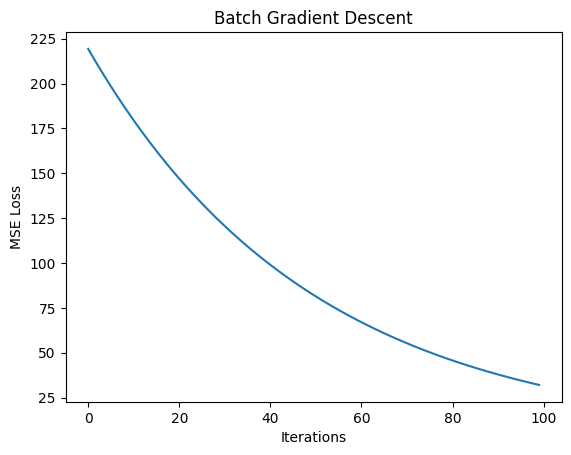

In [11]:
import matplotlib.pyplot as plt

plt.plot(losses_batch)
plt.xlabel("Iterations")
plt.ylabel("MSE Loss")
plt.title("Batch Gradient Descent")
plt.show()

SGD


In [12]:
def sgd(X, y, lr=0.01, epochs=100):
    theta = np.zeros((X.shape[1], 1))
    losses = []

    n = len(y)

    for epoch in range(epochs):
        for i in range(n):
            xi = X[i:i+1]
            yi = y[i:i+1]

            grad = xi.T @ (xi @ theta - yi)

            theta = theta - lr * grad

        y_pred = X @ theta
        losses.append(mse(y, y_pred))

    return theta, losses

In [13]:
theta_sgd, losses_sgd = sgd(X, y)
print("Final MSE (SGD):", losses_sgd[-1])

Final MSE (SGD): 2.8052779496062796


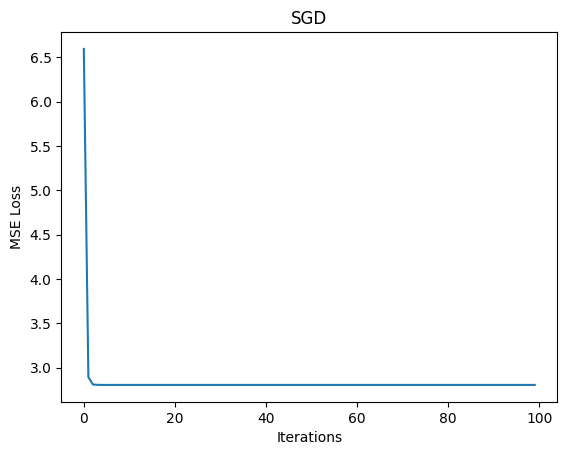

In [14]:
plt.plot(losses_sgd)
plt.xlabel("Iterations")
plt.ylabel("MSE Loss")
plt.title("SGD")
plt.show()

MINI BATCH GD

In [15]:
def mini_batch_gd(X, y, lr=0.01, batch_size=10, epochs=100):
    theta = np.zeros((X.shape[1], 1))
    losses = []

    n = len(y)

    for epoch in range(epochs):
        for i in range(0, n, batch_size):
            Xb = X[i:i+batch_size]
            yb = y[i:i+batch_size]

            grad = (1/len(yb)) * Xb.T @ (Xb @ theta - yb)

            theta = theta - lr * grad

        y_pred = X @ theta
        losses.append(mse(y, y_pred))

    return theta, losses

In [16]:
theta_mb, losses_mb = mini_batch_gd(X, y)
print("Final MSE (Mini-Batch):", losses_mb[-1])

Final MSE (Mini-Batch): 2.784349119624929


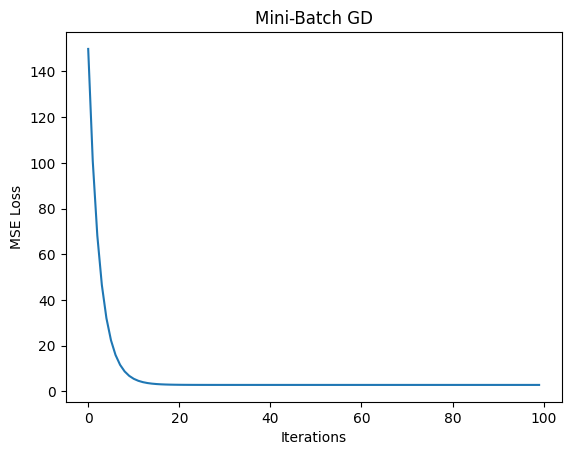

In [17]:
plt.plot(losses_mb)
plt.xlabel("Iterations")
plt.ylabel("MSE Loss")
plt.title("Mini-Batch GD")
plt.show()

MOMENTUM

In [18]:
def momentum(X, y, lr=0.01, gamma=0.9, epochs=100):
    theta = np.zeros((X.shape[1], 1))
    v = np.zeros_like(theta)
    losses = []

    for epoch in range(epochs):
        grad = compute_gradient(X, y, theta)

        v = gamma * v + lr * grad

        theta = theta - v

        y_pred = X @ theta
        losses.append(mse(y, y_pred))

    return theta, losses

In [19]:
theta_mom, losses_mom = momentum(X, y)
print("Final MSE (Momentum):", losses_mom[-1])

Final MSE (Momentum): 2.7857127594894813


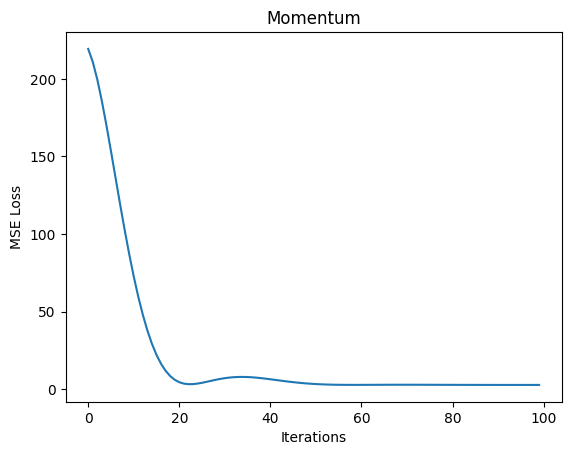

In [20]:
plt.plot(losses_mom)
plt.xlabel("Iterations")
plt.ylabel("MSE Loss")
plt.title("Momentum")
plt.show()

NAG

In [21]:
def nag(X, y, lr=0.01, gamma=0.9, epochs=100):
    theta = np.zeros((X.shape[1], 1))
    v = np.zeros_like(theta)
    losses = []

    for epoch in range(epochs):
        lookahead_theta = theta - gamma * v

        grad = compute_gradient(X, y, lookahead_theta)

        v = gamma * v + lr * grad

        theta = theta - v

        y_pred = X @ theta
        losses.append(mse(y, y_pred))

    return theta, losses

In [22]:
theta_nag, losses_nag = nag(X, y)
print("Final MSE (NAG):", losses_nag[-1])

Final MSE (NAG): 2.7842449851391793


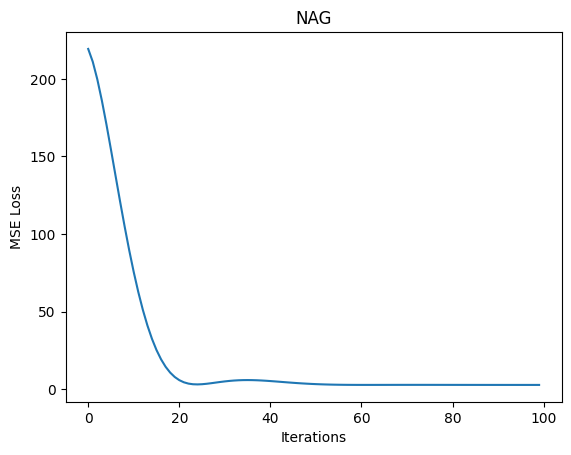

In [23]:
plt.plot(losses_nag)
plt.xlabel("Iterations")
plt.ylabel("MSE Loss")
plt.title("NAG")
plt.show()

ADAGRAD

In [24]:
def adagrad(X, y, lr=0.01, eps=1e-8, epochs=100):
    theta = np.zeros((X.shape[1], 1))
    G = np.zeros_like(theta)
    losses = []

    for epoch in range(epochs):
        grad = compute_gradient(X, y, theta)

        G += grad ** 2

        theta = theta - (lr / (np.sqrt(G) + eps)) * grad

        y_pred = X @ theta
        losses.append(mse(y, y_pred))

    return theta, losses

In [25]:
theta_ada, losses_ada = adagrad(X, y)
print("Final MSE (AdaGrad):", losses_ada[-1])

Final MSE (AdaGrad): 215.66100783987358


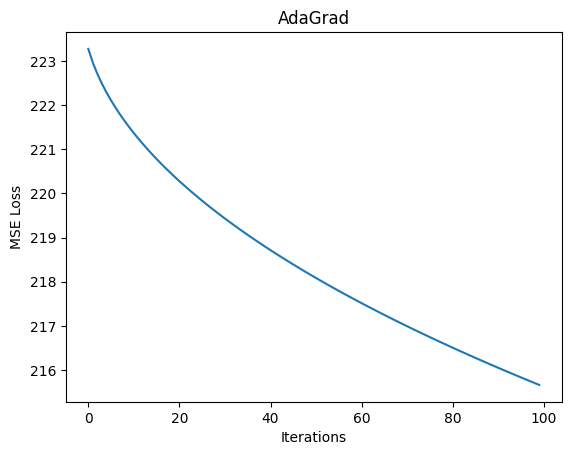

In [26]:
plt.plot(losses_ada)
plt.xlabel("Iterations")
plt.ylabel("MSE Loss")
plt.title("AdaGrad")
plt.show()

RMSPROP

In [27]:
def rmsprop(X, y, lr=0.001, beta=0.9, eps=1e-8, epochs=100):
    theta = np.zeros((X.shape[1], 1))
    Eg = np.zeros_like(theta)
    losses = []

    for epoch in range(epochs):
        grad = compute_gradient(X, y, theta)

        Eg = beta * Eg + (1 - beta) * (grad ** 2)

        theta = theta - (lr / (np.sqrt(Eg) + eps)) * grad

        y_pred = X @ theta
        losses.append(mse(y, y_pred))

    return theta, losses

In [28]:
theta_rms, losses_rms = rmsprop(X, y)
print("Final MSE (RMSProp):", losses_rms[-1])

Final MSE (RMSProp): 218.91942297360026


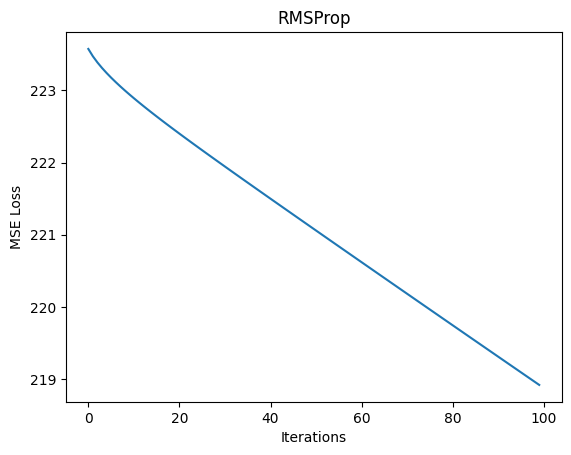

In [29]:
plt.plot(losses_rms)
plt.xlabel("Iterations")
plt.ylabel("MSE Loss")
plt.title("RMSProp")
plt.show()

ADAM

In [30]:
def adam(X, y, lr=0.001, beta1=0.9, beta2=0.999, eps=1e-8, epochs=100):
    theta = np.zeros((X.shape[1], 1))

    m = np.zeros_like(theta)
    v = np.zeros_like(theta)

    losses = []

    for t in range(1, epochs + 1):
        grad = compute_gradient(X, y, theta)

        m = beta1 * m + (1 - beta1) * grad
        v = beta2 * v + (1 - beta2) * (grad ** 2)

        m_hat = m / (1 - beta1 ** t)
        v_hat = v / (1 - beta2 ** t)

        theta = theta - lr * m_hat / (np.sqrt(v_hat) + eps)

        y_pred = X @ theta
        losses.append(mse(y, y_pred))

    return theta, losses

In [31]:
theta_adam, losses_adam = adam(X, y)
print("Final MSE (Adam):", losses_adam[-1])

Final MSE (Adam): 219.32547247488895


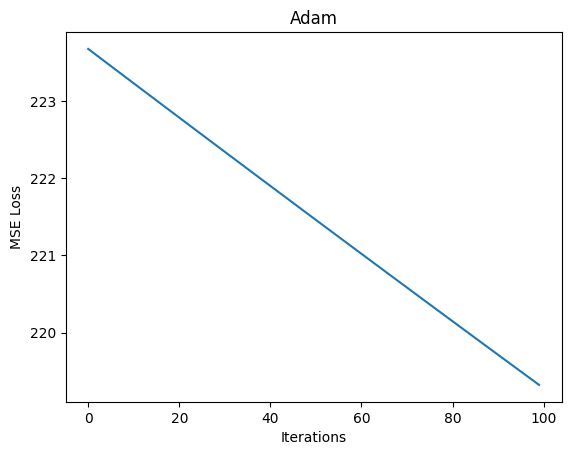

In [32]:
plt.plot(losses_adam)
plt.xlabel("Iterations")
plt.ylabel("MSE Loss")
plt.title("Adam")
plt.show()

BEST OPTIMIZER

In [33]:
results = {}

results['Batch GD'] = batch_gd(X, y)
results['SGD'] = sgd(X, y)
results['Mini-Batch'] = mini_batch_gd(X, y)
results['Momentum'] = momentum(X, y)
results['NAG'] = nag(X, y)
results['AdaGrad'] = adagrad(X, y)
results['RMSProp'] = rmsprop(X, y)
results['Adam'] = adam(X, y)

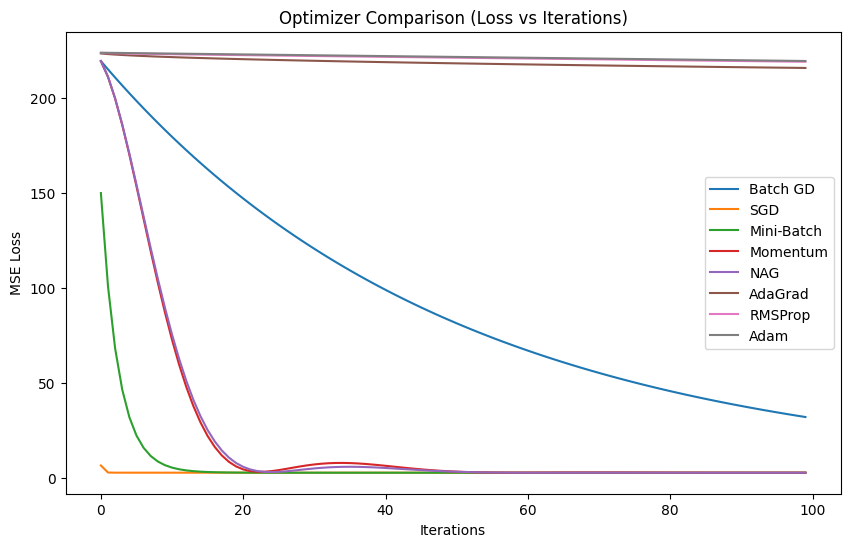

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

for name, (_, losses) in results.items():
    plt.plot(losses, label=name)

plt.xlabel("Iterations")
plt.ylabel("MSE Loss")
plt.title("Optimizer Comparison (Loss vs Iterations)")
plt.legend()
plt.show()

In [35]:
for name, (theta, losses) in results.items():
    print(f"{name}: Final MSE = {losses[-1]:.4f}")

Batch GD: Final MSE = 32.0774
SGD: Final MSE = 2.8053
Mini-Batch: Final MSE = 2.7843
Momentum: Final MSE = 2.7857
NAG: Final MSE = 2.7842
AdaGrad: Final MSE = 215.6610
RMSProp: Final MSE = 218.9194
Adam: Final MSE = 219.3255


NAG is the best optimizer as it has the lowest MSE

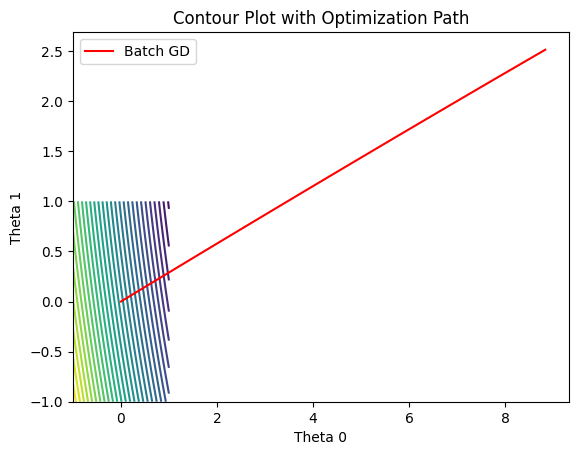

In [36]:
theta0_vals = np.linspace(-1, 1, 100)
theta1_vals = np.linspace(-1, 1, 100)

J = np.zeros((100, 100))

for i in range(100):
    for j in range(100):
        temp_theta = np.zeros((X.shape[1], 1))
        temp_theta[0] = theta0_vals[i]
        temp_theta[1] = theta1_vals[j]
        J[i, j] = mse(y, X @ temp_theta)

plt.contour(theta0_vals, theta1_vals, J.T, levels=30)

def get_path(optimizer_func):
    theta = np.zeros((X.shape[1], 1))
    path = []

    for _ in range(100):
        path.append((theta[0,0], theta[1,0]))
        grad = compute_gradient(X, y, theta)
        theta = theta - 0.01 * grad

    return path

batch_path = get_path(batch_gd)
plt.plot([p[0] for p in batch_path],
         [p[1] for p in batch_path], 'r-', label="Batch GD")

plt.xlabel("Theta 0")
plt.ylabel("Theta 1")
plt.title("Contour Plot with Optimization Path")
plt.legend()
plt.show()